<a href="https://colab.research.google.com/github/kavinkumarManielayaperumal/Toy-Model-for-Gaussian-Mixture-in-Traffic-Scenario-Group-Project./blob/main_toy/2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  ***Necessary libraries***

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive




# ***Standardize data***

# ***Model***


*   Initialization

*   Define E-step (Expectation)
*   Define M-step (Maximization)


*   Combine into EM Algorithm


*   Assign Clusters and Visualize






In [11]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
file_path ='/content/train_features.csv'
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

## ***Initialization***

In [12]:
import numpy as np

# Function to initialize the parameters
def initialize_parameters(X, num_clusters):
    """
    Initializes the parameters for GMM.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).

    Returns:
        means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
        covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
        weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    # Step 1: Initialize means by randomly sampling data points
    initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]

    # Step 2: Initialize covariances as identity matrices
    initial_covariances = [np.eye(n_features)for _ in range(num_clusters)]

    # Step 3: Initialize weights equally
    initial_weights = np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights

# Example usage:
# Assuming `data_standardized` is your standardized dataset
num_clusters = 3  # Number of clusters (e.g., Left, Straight, Right)
means, covariances, weights = initialize_parameters(X, num_clusters)

# Print the initialized parameters
print("Initial Means:\n", means)
print("\nInitial Covariances:\n", covariances)
print("\nInitial Weights:\n", weights)


Initial Means:
 [[0.00697232 0.10141583]
 [0.715266   0.758226  ]
 [0.0103393  0.10682794]]

Initial Covariances:
 [array([[1., 0.],
       [0., 1.]]), array([[1., 0.],
       [0., 1.]]), array([[1., 0.],
       [0., 1.]])]

Initial Weights:
 [0.33333333 0.33333333 0.33333333]


# ***Define E-step (Expectation)***

In [13]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities


# ***Define M-step (Maximization)***

In [14]:
# M-step: Update parameters
def m_step(X, responsibilities, num_clusters):
    n_samples, n_features = X.shape
    weights = responsibilities.sum(axis=0) / n_samples
    means = np.zeros((num_clusters, n_features))
    covariances = []

    for k in range(num_clusters):
        resp = responsibilities[:, k]
        total_resp = resp.sum()

        # Update means
        means[k] = np.sum(resp[:, np.newaxis] * X, axis=0) / total_resp

        # Update covariances
        diff = X - means[k]
        cov = (resp[:, np.newaxis] * diff).T @ diff / total_resp
        covariances.append(cov)

    return means, covariances, weights





# ***Combine into EM Algorithm***




In [15]:
 # that need improvement to handle potential issues such as singular matrices, numerical instability, or divide-by-zero errors.

def run_em_algorithm(X, num_clusters, max_iter=100, tol=1e-6):
    means, covariances, weights = initialize_parameters(X, num_clusters)
    log_likelihood_old = 0

    means_list, covariances_list, weights_list, saved_iterations = [], [], [], []

    for iteration in range(max_iter):
        # E-step
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # M-step
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Regularize covariances
        epsilon = 1e-6
        covariances = [cov + epsilon * np.eye(cov.shape[0]) for cov in covariances]

        # Save parameters
        if iteration % 10 == 0 or iteration == 0:
            means_list.append(means.copy())
            covariances_list.append([cov.copy() for cov in covariances])
            weights_list.append(weights.copy())
            saved_iterations.append(iteration)

        # Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10
            )
        )
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities, means_list, covariances_list, weights_list, saved_iterations


def multivariate_gaussian(X, mean, covariance):
    n_features = X.shape[1]
    epsilon = 1e-6
    covariance += epsilon * np.eye(covariance.shape[0])

    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization


In [16]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 3
max_iter = 100
tol = 1e-6

# Specify iterations for visualization
visualize_steps = [0, 30,60,90]

# Run the EM algorithm with visualization steps
final_means, final_covariances, final_weights, final_responsibilities, means_list, covariances_list, weights_list,saved_iterations = run_em_algorithm(
    X, num_clusters=3, max_iter=100, tol=1e-6)


# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)

Iteration 0, Log-likelihood: -3337440.0011750017
Iteration 1, Log-likelihood: -3281570.747366597
Iteration 2, Log-likelihood: -3145781.638223634
Iteration 3, Log-likelihood: -2840119.5057948306
Iteration 4, Log-likelihood: -2348291.527449853
Iteration 5, Log-likelihood: -1874349.339553556
Iteration 6, Log-likelihood: -1572898.0326325218
Iteration 7, Log-likelihood: -1400824.758865381
Iteration 8, Log-likelihood: -1284695.8475865193
Iteration 9, Log-likelihood: -1184918.3720847566
Iteration 10, Log-likelihood: -1083037.1092943335
Iteration 11, Log-likelihood: -961137.8729841192
Iteration 12, Log-likelihood: -763676.9474440835
Iteration 13, Log-likelihood: -281670.47520213446
Iteration 14, Log-likelihood: 1039127.0878066093
Iteration 15, Log-likelihood: 3037919.3037034953
Iteration 16, Log-likelihood: 4467886.752665236
Iteration 17, Log-likelihood: 5814164.466894781
Iteration 18, Log-likelihood: 7211449.978757132
Iteration 19, Log-likelihood: 8217495.377517667
Iteration 20, Log-likelihoo

#         ***Assign Clusters and Visualize***

In [17]:
print(f"Length of means_list: {len(means_list)}")
print(f"Length of covariances_list: {len(covariances_list)}")
print(f"Length of weights_list: {len(weights_list)}")
print(f"Visualize steps: {saved_iterations}")


Length of means_list: 10
Length of covariances_list: 10
Length of weights_list: 10
Visualize steps: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]


In [18]:
print(f"Length of means_list: {len(means_list)}")
#saved_iterations = list(range(0, len(means_list)))  # Automatically set visualize steps
print(f"Adjusted visualize_steps: {saved_iterations}")


Length of means_list: 10
Adjusted visualize_steps: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]


In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list,saved_iterations, feature_idx1=0, feature_idx2=1):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        visualize_steps (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: 0).
        feature_idx2 (int): Index of the second feature to plot (default: 1).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration}")
        plt.xlabel(f"Feature {feature_idx1 + 1}")
        plt.ylabel(f"Feature {feature_idx2 + 1}")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


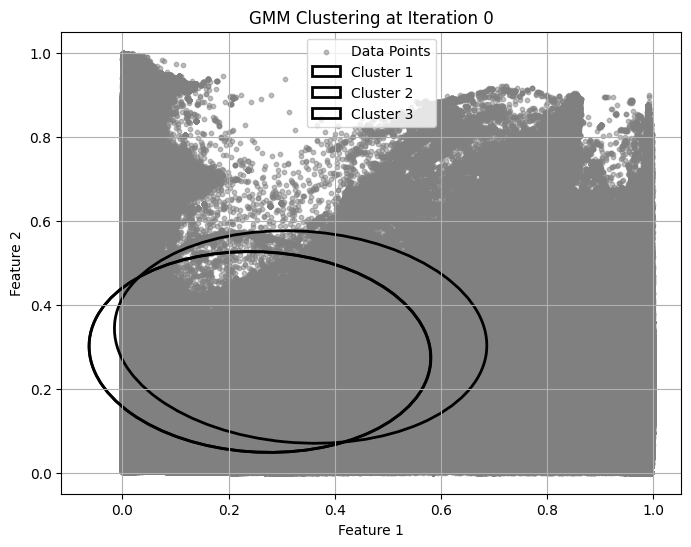

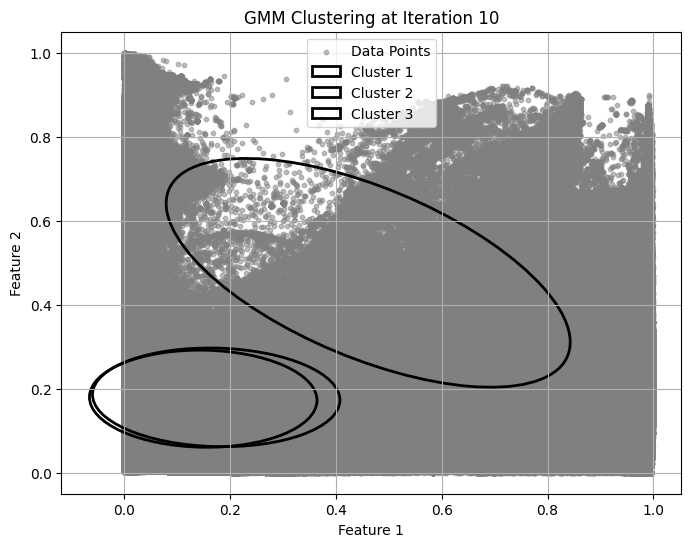

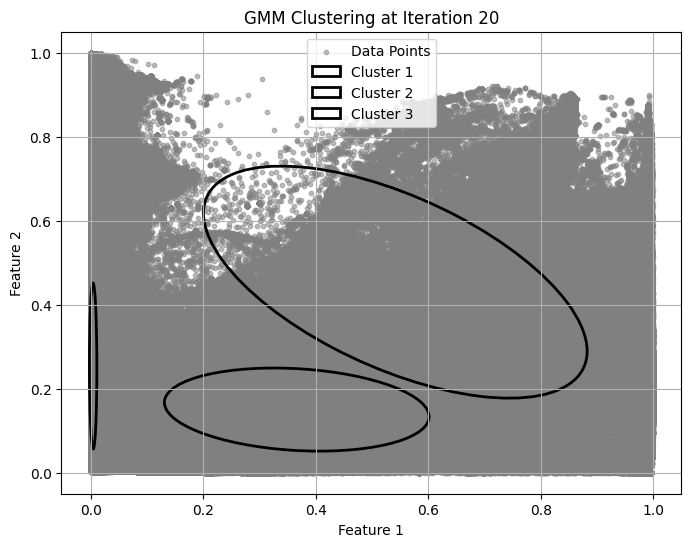

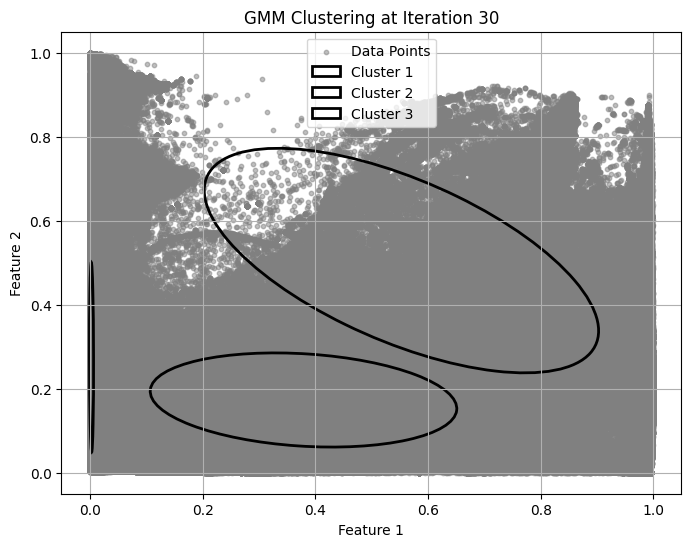

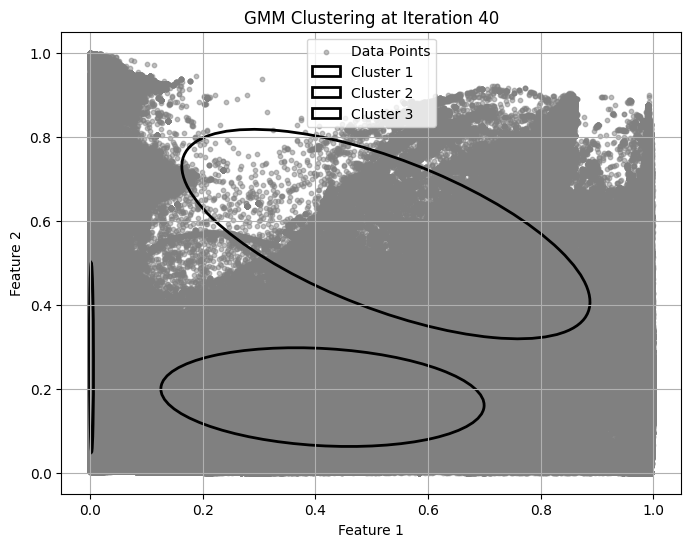

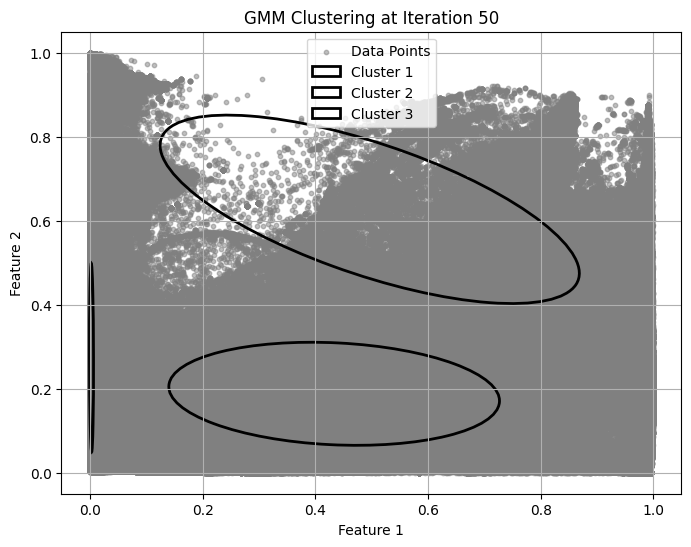

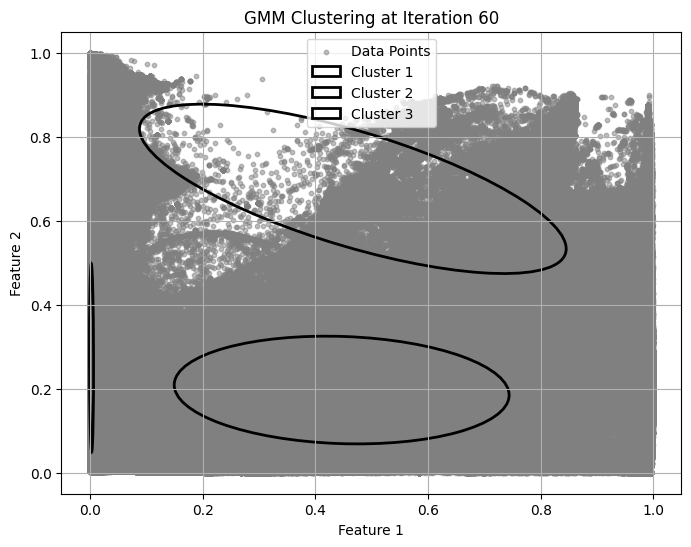

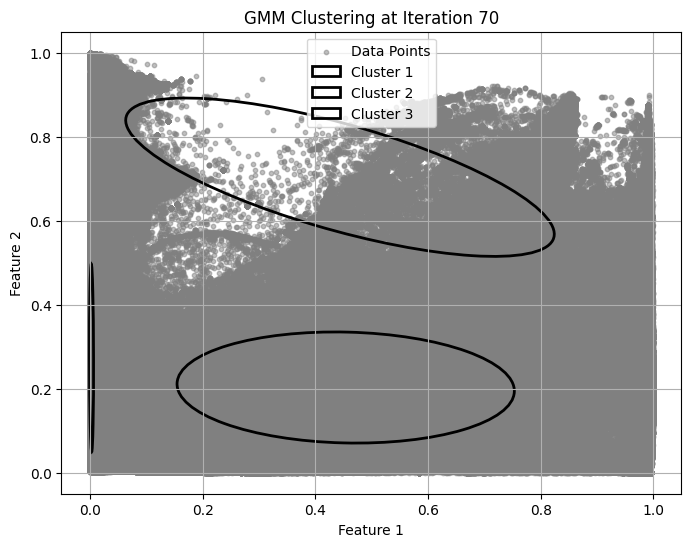

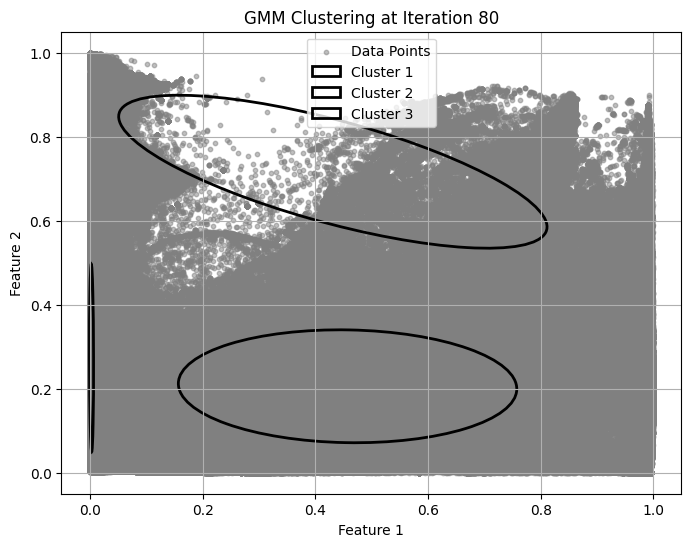

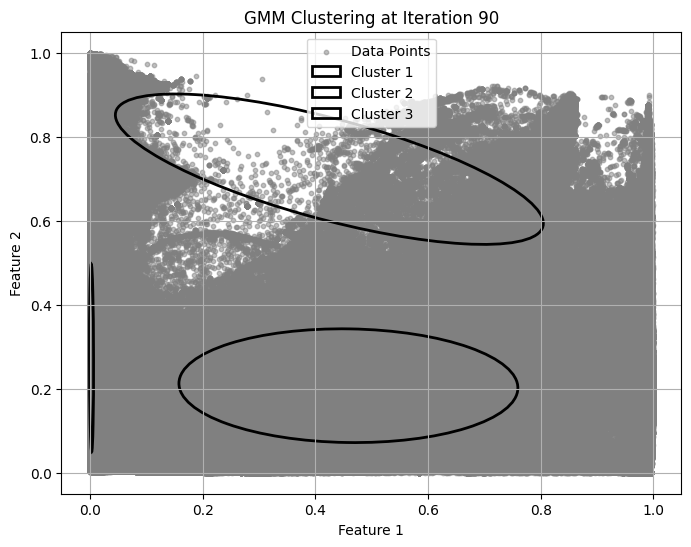

In [20]:
# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=0, feature_idx2=1)


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0):
    """
    Visualizes 1D GMM clustering progression for specified iterations along a single feature axis,
    plotting the probability density functions (PDFs) for each Gaussian component.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list of numpy.ndarray): Means of each Gaussian component for each iteration.
        covariances_list (list of numpy.ndarray): Covariances of each Gaussian component for each iteration.
        weights_list (list of numpy.ndarray): Weights of each Gaussian component for each iteration.
        saved_iterations (list of int): Indices of iterations for which to visualize the clustering.
        feature_idx (int): Index of the feature to plot (default: 0).
    """
    # Determine the range for plotting based on the dataset and expected spread of the Gaussians
    x_min = min([np.min(X[:, feature_idx])] + [m[feature_idx] - 3*np.sqrt(c[feature_idx, feature_idx]) for m, c in zip(means_list[-1], covariances_list[-1])])
    x_max = max([np.max(X[:, feature_idx])] + [m[feature_idx] + 3*np.sqrt(c[feature_idx, feature_idx]) for m, c in zip(means_list[-1], covariances_list[-1])])
    x_range = np.linspace(x_min, x_max, 1000)

    plt.figure(figsize=(10, 6))

    # Plotting each iteration in a subplot
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.subplot(len(saved_iterations), 1, step_idx + 1)
        total_density = np.zeros_like(x_range)

        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx][feature_idx]
            variance = covariances_list[step_idx][cluster_idx][feature_idx, feature_idx]
            weight = weights_list[step_idx][cluster_idx]
            density = norm.pdf(x_range, mean, np.sqrt(variance)) * weight
            plt.plot(x_range, density, label=f'Cluster {cluster_idx + 1}')
            total_density += density

        plt.plot(x_range, total_density, color='black', label='Total Density')
        plt.scatter(X[:, feature_idx], np.full_like(X[:, feature_idx], -0.01), color='gray', alpha=0.5, s=10, marker='|', label="Data Points")
        plt.title(f'GMM 1D Density at Iteration {iteration}')
        plt.xlabel(f'Feature {feature_idx + 1}')
        plt.ylabel('Density')
        plt.legend()

    plt.tight_layout()
    plt.show()

# Example call
# visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)




In [ ]:
# Assuming the following variables are defined:
# X: Data array with shape (n_samples, n_features)
# means_list: List of arrays with the mean of each cluster for each iteration
# covariances_list: List of arrays with the covariance matrices for each iteration
# weights_list: List of arrays with the weights of each cluster for each iteration
# saved_iterations: List of iteration indices you want to visualize (e.g., [0, 2, 4, 10])

# Call the function to visualize the progression for a specific feature (e.g., feature_idx=0 for the first feature)
visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0):
    """
    Visualizes 1D GMM clustering progression for specified iterations along a single feature axis,
    with each iteration shown in a separate and independent figure.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list of numpy.ndarray): Means of each Gaussian component for each iteration.
        covariances_list (list of numpy.ndarray): Covariances of each Gaussian component for each iteration.
        weights_list (list of numpy.ndarray): Weights of each Gaussian component for each iteration.
        saved_iterations (list of int): Indices of iterations for which to visualize the clustering.
        feature_idx (int): Index of the feature to plot (default: 0).
    """
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        x_min = np.min(X[:, feature_idx]) - 3
        x_max = np.max(X[:, feature_idx]) + 3
        x_range = np.linspace(x_min, x_max, 1000)

        plt.figure(figsize=(10, 6))  # Create a new figure for each iteration
        total_density = np.zeros_like(x_range)

        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx][feature_idx]
            variance = covariances_list[step_idx][cluster_idx][feature_idx, feature_idx]
            weight = weights_list[step_idx][cluster_idx]
            density = norm.pdf(x_range, mean, np.sqrt(variance)) * weight
            plt.plot(x_range, density, label=f'Cluster {cluster_idx + 1}', linestyle='--')

        total_density += density
        plt.plot(x_range, total_density, color='black', label='Total Density')
        plt.scatter(X[:, feature_idx], -0.005 * np.ones_like(X[:, feature_idx]), color='gray', alpha=0.5, s=10, marker='|', label="Data Points")
        plt.title(f'GMM 1D Density at Iteration {iteration}')
        plt.xlabel(f'Feature {feature_idx + 1}')
        plt.ylabel('Density')
        plt.legend()
        plt.show()

# Example call to this function
# Assuming the following variables are defined:
# X: Data array with shape (n_samples, n_features)
# means_list: List of arrays with the mean of each cluster for each iteration
# covariances_list: List of arrays with the covariance matrices for each iteration
# weights_list: List of arrays with the weights of each cluster for each iteration
# saved_iterations: List of iteration indices you want to visualize (e.g., [0, 2, 4, 10])

# Call the function to visualize the progression for a specific feature (e.g., feature_idx=0 for the first feature)
visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0, x_limits=None, y_limits=None):
    """
    Visualizes 1D GMM clustering progression for specified iterations along a single feature axis,
    with each iteration shown in a separate and independent figure.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list of numpy.ndarray): Means of each Gaussian component for each iteration.
        covariances_list (list of numpy.ndarray): Covariances of each Gaussian component for each iteration.
        weights_list (list of numpy.ndarray): Weights of each Gaussian component for each iteration.
        saved_iterations (list of int): Indices of iterations for which to visualize the clustering.
        feature_idx (int): Index of the feature to plot (default: 0).
        x_limits (tuple): Tuple of (min, max) to set the x-axis limits.
        y_limits (tuple): Tuple of (min, max) to set the y-axis limits.
    """
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        x_range = np.linspace(x_limits[0] if x_limits else np.min(X[:, feature_idx]) - 3,
                              x_limits[1] if x_limits else np.max(X[:, feature_idx]) + 3, 1000)

        plt.figure(figsize=(10, 6))  # Create a new figure for each iteration
        total_density = np.zeros_like(x_range)

        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx][feature_idx]
            variance = covariances_list[step_idx][cluster_idx][feature_idx, feature_idx]
            weight = weights_list[step_idx][cluster_idx]
            density = norm.pdf(x_range, mean, np.sqrt(variance)) * weight
            plt.plot(x_range, density, label=f'Cluster {cluster_idx + 1}', linestyle='--')

        total_density += density
        plt.plot(x_range, total_density, color='black', label='Total Density')
        plt.scatter(X[:, feature_idx], -0.005 * np.ones_like(X[:, feature_idx]), color='gray', alpha=0.5, s=10, marker='|', label="Data Points")
        plt.title(f'GMM 1D Density at Iteration {iteration}')
        plt.xlabel(f'Feature {feature_idx + 1}')
        plt.ylabel('Density')
        if x_limits:
            plt.xlim(x_limits)
        if y_limits:
            plt.ylim(y_limits)
        plt.legend()
        plt.show()

# Assuming the following variables are defined elsewhere in your code:
# X: Data array with shape (n_samples, n_features)
# means_list: List of arrays with the mean of each cluster for each iteration
# covariances_list: List of arrays with the covariance matrices for each iteration
# weights_list: List of arrays with the weights of each cluster for each iteration
# saved_iterations: List of iteration indices you want to visualize (e.g., [0, 2, 4, 10])

# Example call to visualize the progression for a specific feature (e.g., feature_idx=0 for the first feature)

visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)


In [ ]:
# Old one from 6th January 19:42

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0):
    """
    Visualizes 1D GMM clustering progression for specified iterations along a single feature axis,
    with dynamic Y-axis scaling and custom X-axis limits.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list of numpy.ndarray): Means of each Gaussian component for each iteration.
        covariances_list (list of numpy.ndarray): Covariances of each Gaussian component for each iteration.
        weights_list (list of numpy.ndarray): Weights of each Gaussian component for each iteration.
        saved_iterations (list of int): Indices of iterations for which to visualize the clustering.
        feature_idx (int): Index of the feature to plot (default: 0).
    """
    x_range = np.linspace(-10, 10, 1000)  # Static x-axis limits

    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(10, 6))  # Create a new figure for each iteration
        total_density = np.zeros_like(x_range)

        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx][feature_idx]
            variance = covariances_list[step_idx][cluster_idx][feature_idx, feature_idx]
            weight = weights_list[step_idx][cluster_idx]
            density = norm.pdf(x_range, mean, np.sqrt(variance)) * weight
            plt.plot(x_range, density, label=f'Cluster {cluster_idx + 1}', linestyle='--')
            total_density += density

        plt.plot(x_range, total_density, color='black', label='Total Density')
        plt.scatter(X[:, feature_idx], -0.005 * np.ones_like(X[:, feature_idx]), color='gray', alpha=0.5, s=10, marker='|', label="Data Points")
        plt.title(f'GMM 1D Density at Iteration {iteration}')
        plt.xlabel(f'Feature {feature_idx + 1}')
        plt.ylabel('Density')

        # Dynamic adjustment of y-axis based on the highest density value observed
        data_min, data_max = np.min(X[:, feature_idx]), np.max(X[:, feature_idx])
        max_density = np.max(total_density)
        plt.ylim(0, max_density * 2)  # Scale y-axis to double the max density value


        plt.xlim(data_min - 4, data_max + 3)  # Set x-axis limits
        plt.tick_params(axis='x', which='both', pad=15)
        plt.legend()
        plt.show()

# Assuming the following variables are defined elsewhere in your code:
# X: Data array with shape (n_samples, n_features)
# means_list: List of arrays with the mean of each cluster for each iteration
# covariances_list: List of arrays with the covariance matrices for each iteration
# weights_list: List of arrays with the weights of each cluster for each iteration
# saved_iterations: List of iteration indices you want to visualize (e.g., [0, 2, 4, 10])

# Example call to visualize the progression for a specific feature (e.g., feature_idx=0 for the first feature)
visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)


In [ ]:
#old one-2 06 jan 2025
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0):
    """
    Visualizes 1D GMM clustering progression for specified iterations along a single feature axis,
    with dynamic Y-axis scaling and custom X-axis limits.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list of numpy.ndarray): Means of each Gaussian component for each iteration.
        covariances_list (list of numpy.ndarray): Covariances of each Gaussian component for each iteration.
        weights_list (list of numpy.ndarray): Weights of each Gaussian component for each iteration.
        saved_iterations (list of int): Indices of iterations for which to visualize the clustering.
        feature_idx (int): Index of the feature to plot (default: 0).
    """
    x_range = np.linspace(-10, 10, 1000)  # Static x-axis limits
    customLabels = ['Keeping Lane', 'Right Lane Change', 'Left Lane Change'];

    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        plt.figure(figsize=(10, 6))  # Create a new figure for each iteration
        total_density = np.zeros_like(x_range)

        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx][feature_idx]
            variance = covariances_list[step_idx][cluster_idx][feature_idx, feature_idx]
            weight = weights_list[step_idx][cluster_idx]
            density = norm.pdf(x_range, mean, np.sqrt(variance)) * weight
            plt.plot(x_range, density, label=f'Cluster {cluster_idx + 1}', linestyle='--')
            total_density += density

        plt.plot(x_range, total_density, color='black', label='Total Density')
        custom_label = customLabels[cluster_idx]
        plt.scatter(X[:, feature_idx], -0.005 * np.ones_like(X[:, feature_idx]), color='gray', alpha=0.5, s=10, marker='|', label=custom_label)
        plt.title(f'GMM 1D Density at Iteration {iteration}')
        plt.xlabel(f'Feature {feature_idx + 1}')
        plt.ylabel('Density')

        # Dynamic adjustment of y-axis based on the highest density value observed
        data_min, data_max = np.min(X[:, feature_idx]), np.max(X[:, feature_idx])
        max_density = np.max(total_density)
        plt.ylim(0, max_density * 2)  # Scale y-axis to double the max density value


        plt.xlim(data_min - 0.5, data_max + 1.5)  # Set x-axis limits
        plt.tick_params(axis='x', which='both', pad=15)
        plt.legend()
        plt.show()

# Assuming the following variables are defined elsewhere in your code:
# X: Data array with shape (n_samples, n_features)
# means_list: List of arrays with the mean of each cluster for each iteration
# covariances_list: List of arrays with the covariance matrices for each iteration
# weights_list: List of arrays with the weights of each cluster for each iteration
# saved_iterations: List of iteration indices you want to visualize (e.g., [0, 2, 4, 10])

# Example call to visualize the progression for a specific feature (e.g., feature_idx=0 for the first feature)
#visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)


In [ ]:
#new one
n_samples, n_features = X.shape
for i in range(n_features):
    visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=i)


In [ ]:
#old one-2 06 jan 2025
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_gmm_3d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0):
    """
    Visualizes 1D GMM clustering progression for specified iterations along a single feature axis,
    with dynamic Y-axis scaling and custom X-axis limits.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list of numpy.ndarray): Means of each Gaussian component for each iteration.
        covariances_list (list of numpy.ndarray): Covariances of each Gaussian component for each iteration.
        weights_list (list of numpy.ndarray): Weights of each Gaussian component for each iteration.
        saved_iterations (list of int): Indices of iterations for which to visualize the clustering.
        feature_idx (int): Index of the feature to plot (default: 0).
    """
    x_range = np.linspace(-10, 10, 1000)  # Static x-axis limits

    # 3D Plot Loop
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue

        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        total_density = np.zeros_like(x_range)

        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            variance = covariances_list[step_idx][cluster_idx][0, 0]
            weight = weights_list[step_idx][cluster_idx]
            density = norm.pdf(x_range, mean, np.sqrt(variance)) * weight

            # Plotting each cluster's density in 3D
            ax.plot(x_range, [iteration] * len(x_range), density, label=f'Cluster {cluster_idx + 1}')

            total_density += density

        # Plot total density in black
        ax.plot(x_range, [iteration] * len(x_range), total_density, color='black', label='Total Density')

        # Setting labels
        ax.set_xlabel(f'Feature {step_idx + 1}')
        ax.set_ylabel('Iteration')
        ax.set_zlabel('Density')
        ax.legend()

        plt.show()

# Assuming the following variables are defined elsewhere in your code:
# X: Data array with shape (n_samples, n_features)
# means_list: List of arrays with the mean of each cluster for each iteration
# covariances_list: List of arrays with the covariance matrices for each iteration
# weights_list: List of arrays with the weights of each cluster for each iteration
# saved_iterations: List of iteration indices you want to visualize (e.g., [0, 2, 4, 10])

# Example call to visualize the progression for a specific feature (e.g., feature_idx=0 for the first feature)
#visualize_gmm_1d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)

visualize_gmm_3d_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx=0)
